# Load libraries and set device up

In [1]:
import numpy as np
import torch.nn as nn
import os
import torch

import libraries.model as clm
import libraries.dataset as cld

from torch_geometric.loader import DataLoader

# Checking if pytorch can run in GPU, else CPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

c:\Users\mateu\Desktop\gnn-material-science\gnn-material-science\gnn-material-science\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
import os
print(os.getcwd())

c:\Users\mateu\Desktop\gnn-material-science\gnn-material-science\gnn-material-science


In [3]:
folder = 'free-energies'

target_folder = f'models/{folder}'

In [4]:
from datetime import datetime

# Create timestamped folder for this model run
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
timestamped_folder = f'{target_folder}/results_{timestamp}'
os.makedirs(timestamped_folder, exist_ok=True)

print(f'Model results will be saved to: {timestamped_folder}')

Model results will be saved to: models/free-energies/results_20260409_154940


In [5]:
files_names = {
    # Reusable files (common for all models)
    'dataset':              f'{target_folder}/dataset.pt',
    'std_parameters':       f'{target_folder}/standardized_parameters.json',
    'dataset_parameters':   f'{target_folder}/dataset_parameters.json',
    
    # Model-specific files (unique per model run)
    'train_dataset_std':    f'{timestamped_folder}/train_dataset_std.pt',
    'val_dataset_std':      f'{timestamped_folder}/val_dataset_std.pt',
    'test_dataset_std':     f'{timestamped_folder}/test_dataset_std.pt',
    'model':                f'{timestamped_folder}/model.pt',
    'model_parameters':     f'{timestamped_folder}/model_parameters.json'
}
cld.save_json(files_names, f'{timestamped_folder}/files_names.json')

# Define parameters

In [6]:
n_epochs =      50
batch_size =    128
learning_rate = 0.0001
dropout =       0.2
patience =      n_epochs
delta =         2
train_ratio =   0.8
val_ratio =     0.1
test_ratio =    0.1
max_samples =   None

model_parameters = {
    'n_epochs':      n_epochs,
    'batch_size':    batch_size,
    'learning_rate': learning_rate,
    'dropout':       dropout,
    'patience':      patience,
    'delta':         delta,
    'train_ratio':   train_ratio,
    'val_ratio':     val_ratio,
    'test_ratio':    test_ratio,
    'max_samples':   max_samples
}
cld.save_json(model_parameters, files_names['model_parameters'])

# Generate or load graph database for training

In [7]:
# Try loading the training datasets directly, else generate them
# Generate data
cld.generate_dataset('input/candidates',
                        targets=['bandgap'],
                        data_folder=target_folder,
                        max_samples=max_samples)

Loaded existing dataset with 112159 samples.
Dataset has 112159 samples. Since max_samples=None, checking if all materials are processed...
Ag
Ag(AsSe2)3
Ag(AuF4)2
Ag(AuS)2
Ag(BCl)6
Ag(Bi2S3)3
Ag(BiSe2)3
Ag(BiTe2)3
Ag(CO)2
Ag(H7O4)2
Ag(Mo3S4)2
Ag(Mo3Se4)2
Ag(MoSe)3
Ag(NO)3
Ag(NO2)3
Ag(Te5Au2)2
Ag(TeMo)6
Ag(W3Br7)2
Ag10Te4Br3
Ag10Te4BrCl
Ag11Hg9
Ag12SBr
Ag12SI
Ag12Sn7H16(Se11N2)2
Ag13(BiI4)14
Ag13(PbO3)6
Ag13As3(IO3)4
Ag13Bi15I64
Ag14H8I4(OF2)5
Ag15(BiI4)16
Ag15Bi7I40
Ag15P4S16Cl3
Ag15S5I4Br
Ag15W7N19
Ag16HgAs4S15
Ag2(MoO4)3
Ag2(RhS)15
Ag25(BiO6)3
Ag2As2O7
Ag2As3S6N
Ag2AsO2
Ag2AsS2
Ag2AsS4N
Ag2Au3N6Cl17
Ag2B8O13
Ag2BBr
Ag2Bi2S3Cl2
Ag2Bi2SeS3
Ag2BiO3
Ag2BiSb(TeSe)2
Ag2BiSbSe4
Ag2BiSbTe4
Ag2Br3
Ag2BrNO3
Ag2C4Br3N
Ag2C4I3N
Ag2CN2
Ag2CO3
Ag2CSNClO4
Ag2Cl3
Ag2F
Ag2F3
Ag2F5
Ag2Ge(S2O7)3
Ag2Ge2O5
Ag2GeO3
Ag2GeO4
Ag2GePbS4
Ag2GeS3
Ag2GeSe3
Ag2H12C3S3(BrN3)2
Ag2H12C6N3Cl
Ag2H12S(NO)4
Ag2H16O9
Ag2H21N7(ClO4)2
Ag2H2C2N6O13
Ag2H2IOF
Ag2H3IO6
Ag2H4(SO4)3
Ag2H6PdS2(NO3)2
Ag2H8C2S2N5ClO3
Ag2Hg
Ag2Hg(S

In [8]:
# Load the raw dataset, with corresponding labels, and standardize it
dataset = torch.load(files_names['dataset'], weights_only=False)

# Split datasets
train_dataset, val_dataset, test_dataset = cld.split_dataset(train_ratio, val_ratio, test_ratio, dataset)
del dataset  # Free up CUDA memory

# Standardize train dataset
train_dataset_std, standardized_parameters = cld.standardize_dataset(train_dataset, transformation='inverse-quadratic')

# Standardize test and validation datasets with train parameters
val_dataset_std  = cld.standardize_dataset_from_keys(val_dataset,  standardized_parameters)
test_dataset_std = cld.standardize_dataset_from_keys(test_dataset, standardized_parameters)

# Save datasets to model-specific folder
cld.save_datasets(train_dataset_std, val_dataset_std, test_dataset_std, files_names)

# Save standardized parameters to reusable folder (only if not already there)
if not os.path.exists(files_names['std_parameters']):
    cld.save_json(standardized_parameters, files_names['std_parameters'])

# Defining target factor
target_factor = np.array(standardized_parameters['target_std']) / standardized_parameters['scale']
target_mean    = standardized_parameters['target_mean']

Number of training   graphs: 89727
Number of validation graphs: 11215
Number of testing    graphs: 11215
Graphs after finite check: 89727


Define data loaders.

In [9]:
train_loader = DataLoader(train_dataset_std, batch_size=batch_size, shuffle=False, pin_memory=True)
val_loader   = DataLoader(val_dataset_std,   batch_size=batch_size, shuffle=False, pin_memory=True)
test_loader  = DataLoader(test_dataset_std,  batch_size=batch_size, shuffle=False, pin_memory=True)

# Determine number of node-level features in dataset, considering the t_step information
n_node_features = train_dataset_std[0].num_node_features

# Generate Graph Neural Network model

In [ ]:
model = clm.load_model(n_node_features, dropout, device, model_name=files_names['model'], mode='train')
model

# Train

Define training optimized and criterion

In [ ]:
# MSELoss is by default defined as the mean within the batch
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
criterion = torch.nn.MSELoss()

# Initialize early stopping
early_stopping = clm.EarlyStopping(patience=patience, delta=delta, model_name=files_names['model'])

In [ ]:
# Train the model
train_losses = []
val_losses   = []
for epoch in np.arange(0, n_epochs):
    train_loss, train_predictions, train_ground_truths = clm.train(model, criterion, train_loader,
                                                                   target_factor,
                                                                   standardized_parameters['target_mean'],
                                                                   optimizer)
    val_loss,   val_predictions,   val_ground_truths   =  clm.test(model, criterion, val_loader,
                                                                   target_factor,
                                                                   standardized_parameters['target_mean'])

    # Convert to original units
    train_loss = np.sum(np.sqrt(train_loss) * target_factor)
    val_loss   = np.sum(np.sqrt(val_loss)   * target_factor)

    if epoch%10 == 0:
        cld.parity_plot(train=np.array([train_ground_truths, train_predictions]),
                        validation=np.array([val_ground_truths, val_predictions]))
    
    # Append losses
    train_losses.append(train_loss)
    val_losses.append(val_loss)

    # Check early stopping criteria
    early_stopping(val_loss, model)

    if early_stopping.early_stop:
        print('Early stopping')
        break

    print(f'Epoch: {epoch+1}, Train MAE: {train_loss:.4f}, Val MAE: {val_loss:.4f}')

In [ ]:
cld.losses_plot(train_losses=train_losses,
                val_losses=val_losses,
                to_log=True)

# Check test data

In [ ]:
model = clm.load_model(n_node_features, dropout, device, model_name=files_names['model'], mode='eval')
model

In [ ]:
train_loss, train_predictions, train_ground_truths = clm.test(model, criterion, train_loader,
                                                              target_factor,
                                                              standardized_parameters['target_mean'])
val_loss,   val_predictions,   val_ground_truths   = clm.test(model, criterion, val_loader,
                                                              target_factor,
                                                              standardized_parameters['target_mean'])
test_loss,  test_predictions,  test_ground_truths  = clm.test(model, criterion, test_loader,
                                                              target_factor,
                                                              standardized_parameters['target_mean'])

# Pass to energy units (same as initial Fv)
train_loss = np.sum(np.sqrt(train_loss) * target_factor)
val_loss   = np.sum(np.sqrt(val_loss)   * target_factor)
test_loss  = np.sum(np.sqrt(test_loss)  * target_factor)

cld.parity_plot(train=np.array([train_ground_truths, train_predictions]),
                validation=np.array([val_ground_truths, val_predictions]),
                test=np.array([test_ground_truths, test_predictions]),
                save_to=f'{timestamped_folder}/GCNN-training.pdf')

print(f'Train MAE: {train_loss:.4f}, Val MAE: {val_loss:.4f}, Test MAE: {test_loss:.4f}')

In [ ]:
import json

# Save detailed results to the timestamped model folder
results_data = {
    'timestamp': timestamp,
    'model_parameters': model_parameters,
    'training_history': {
        'train_losses': [float(loss) for loss in train_losses],
        'val_losses': [float(loss) for loss in val_losses],
        'epochs_completed': len(train_losses)
    },
    'final_metrics': {
        'train_mae': float(train_loss),
        'val_mae': float(val_loss),
        'test_mae': float(test_loss)
    },
    'predictions': {
        'train': {
            'predicted': train_predictions.tolist(),
            'actual': train_ground_truths.tolist()
        },
        'validation': {
            'predicted': val_predictions.tolist(),
            'actual': val_ground_truths.tolist()
        },
        'test': {
            'predicted': test_predictions.tolist(),
            'actual': test_ground_truths.tolist()
        }
    }
}

results_file = f'{timestamped_folder}/model_results_{timestamp}.json'
with open(results_file, 'w') as f:
    json.dump(results_data, f, indent=4)

print(f'Model results saved to: {results_file}')

In [142]:
import importlib
importlib.reload(cld)

<module 'libraries.dataset' from 'c:\\Users\\mateu\\Desktop\\gnn-material-science\\gnn-material-science\\gnn-material-science\\libraries\\dataset.py'>

# Load libraries and set device up

In [111]:
import numpy as np
import torch.nn as nn
import os
import torch

import libraries.model as clm
import libraries.dataset as cld

from torch_geometric.loader import DataLoader

# Checking if pytorch can run in GPU, else CPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [112]:
import os
print(os.getcwd())

c:\Users\mateu\Desktop\gnn-material-science\gnn-material-science\gnn-material-science


In [113]:
folder = 'free-energies'

target_folder = f'models/{folder}'

In [114]:
from datetime import datetime

# Create timestamped folder for this model run
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
timestamped_folder = f'{target_folder}/results_{timestamp}'
os.makedirs(timestamped_folder, exist_ok=True)

print(f'Model results will be saved to: {timestamped_folder}')

Model results will be saved to: models/free-energies/results_20260409_125306


In [115]:
files_names = {
    # Reusable files (common for all models)
    'dataset':              f'{target_folder}/dataset.pt',
    'std_parameters':       f'{target_folder}/standardized_parameters.json',
    'dataset_parameters':   f'{target_folder}/dataset_parameters.json',
    
    # Model-specific files (unique per model run)
    'train_dataset_std':    f'{timestamped_folder}/train_dataset_std.pt',
    'val_dataset_std':      f'{timestamped_folder}/val_dataset_std.pt',
    'test_dataset_std':     f'{timestamped_folder}/test_dataset_std.pt',
    'model':                f'{timestamped_folder}/model.pt',
    'model_parameters':     f'{timestamped_folder}/model_parameters.json'
}
cld.save_json(files_names, f'{timestamped_folder}/files_names.json')

# Define parameters

In [116]:
n_epochs =      50
batch_size =    128
learning_rate = 0.0001
dropout =       0.2
patience =      n_epochs
delta =         2
train_ratio =   0.8
val_ratio =     0.1
test_ratio =    0.1
max_samples =   100

model_parameters = {
    'n_epochs':      n_epochs,
    'batch_size':    batch_size,
    'learning_rate': learning_rate,
    'dropout':       dropout,
    'patience':      patience,
    'delta':         delta,
    'train_ratio':   train_ratio,
    'val_ratio':     val_ratio,
    'test_ratio':    test_ratio,
    'max_samples':   max_samples
}
cld.save_json(model_parameters, files_names['model_parameters'])

# Generate or load graph database for training

In [117]:
# Try loading the training datasets directly, else generate them
# Generate data
cld.generate_dataset('input/candidates',
                        targets=['bandgap'],
                        data_folder=target_folder,
                        max_samples=max_samples)

# Load the raw dataset, with corresponding labels, and standardize it
dataset = torch.load(files_names['dataset'], weights_only=False)

# Split datasets
train_dataset, val_dataset, test_dataset = cld.split_dataset(train_ratio, val_ratio, test_ratio, dataset)
del dataset  # Free up CUDA memory

# Standardize train dataset
train_dataset_std, standardized_parameters = cld.standardize_dataset(train_dataset, transformation='inverse-quadratic')

# Standardize test and validation datasets with train parameters
val_dataset_std  = cld.standardize_dataset_from_keys(val_dataset,  standardized_parameters)
test_dataset_std = cld.standardize_dataset_from_keys(test_dataset, standardized_parameters)

# Save datasets to model-specific folder
cld.save_datasets(train_dataset_std, val_dataset_std, test_dataset_std, files_names)

# Save standardized parameters to reusable folder (only if not already there)
if not os.path.exists(files_names['std_parameters']):
    cld.save_json(standardized_parameters, files_names['std_parameters'])

# Defining target factor
target_factor = np.array(standardized_parameters['target_std']) / standardized_parameters['scale']
target_mean    = standardized_parameters['target_mean']

Ag
	Fm-3m
	Im-3m
	P6_3-mmc
	R-3m
Ag(AsSe2)3
	Cmmm
Ag(AuF4)2
	P2_1-c
Ag(AuS)2
	Pc
Ag(BCl)6
	Pa-3
Ag(Bi2S3)3
	C2-m
Ag(BiSe2)3
	Cmmm
Ag(BiTe2)3
	Cmmm
Ag(CO)2
	C2
	C2-c
Ag(H7O4)2
	P2_1-c
Ag(Mo3S4)2
	R-3
Ag(Mo3Se4)2
	R-3
Ag(MoSe)3
	P6_3-m
Ag(NO)3
	Pnnm
Ag(NO2)3
	P2_1-c
Ag(Te5Au2)2
	C2-m
Ag(TeMo)6
	C2-m
Ag(W3Br7)2
	Pn-3
Ag10Te4Br3
	Cmc2_1
	Cmcm
Ag10Te4BrCl
	P2_1-c
Ag11Hg9
	P3m1
Ag12SBr
	Pm-3m
Ag12SI
	Pm-3m
Ag12Sn7H16(Se11N2)2
	C2-c
Ag13(BiI4)14
	P-1
Ag13(PbO3)6
	P1
Ag13As3(IO3)4
	P2_1-m
Ag13Bi15I64
	P1
Ag14H8I4(OF2)5
	P2_1
Ag15(BiI4)16
	P-1
Ag15Bi7I40
	Cm
Ag15P4S16Cl3
	I-43d
Ag15S5I4Br
	P1
Ag15W7N19
	P-1
Ag16HgAs4S15
	C2
Ag2(MoO4)3
	Pnma
Ag2(RhS)15
	Pm-3m
Ag25(BiO6)3
	P-3
Ag2As2O7
	P2_1-c
Ag2As3S6N
	P2_1-c
Ag2AsO2
	Fddd
Ag2AsS2
	Pc
Ag2AsS4N
	I-42m
Ag2Au3N6Cl17
	Immm
Ag2B8O13
	P1
	P2_1
	P2_1-c
Ag2BBr
	Fm-3m
Ag2Bi2S3Cl2
	P-1
Ag2Bi2SeS3
	Imm2
Ag2BiO3
	Pc
	Pnn2
	Pnna
Ag2BiSb(TeSe)2
	Imm2
Ag2BiSbSe4
	I-4m2
Ag2BiSbTe4
	I-4m2
Ag2Br3
	R-3c
Ag2BrNO3
	Pnma
Ag2C4Br3N
	Pnma
Ag2C4I3N
	Pnma
Ag2Cl3
	R-3c
A

TypeError: split_dataset() takes 3 positional arguments but 4 were given

Define data loaders.

In [ ]:
train_loader = DataLoader(train_dataset_std, batch_size=batch_size, shuffle=False, pin_memory=True)
val_loader   = DataLoader(val_dataset_std,   batch_size=batch_size, shuffle=False, pin_memory=True)
test_loader  = DataLoader(test_dataset_std,  batch_size=batch_size, shuffle=False, pin_memory=True)

# Determine number of node-level features in dataset, considering the t_step information
n_node_features = train_dataset_std[0].num_node_features

# Generate Graph Neural Network model

In [ ]:
model = clm.load_model(n_node_features, dropout, device, model_name=files_names['model'], mode='train')
model

DataParallel(
  (module): GCNN(
    (conv1): GraphConv(4, 512)
    (conv2): GraphConv(512, 512)
    (linconv1): Linear(in_features=512, out_features=64, bias=True)
    (linconv2): Linear(in_features=64, out_features=16, bias=True)
    (lin): Linear(in_features=16, out_features=1, bias=True)
  )
)

# Train

Define training optimized and criterion

In [ ]:
# MSELoss is by default defined as the mean within the batch
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
criterion = torch.nn.MSELoss()

# Initialize early stopping
early_stopping = clm.EarlyStopping(patience=patience, delta=delta, model_name=files_names['model'])

c:\Users\mateu\Desktop\gnn-material-science\gnn-material-science\gnn-material-science\.venv\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


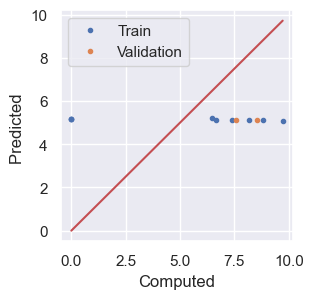

Epoch: 1, Train MAE: 3.8483, Val MAE: 2.9622
Epoch: 2, Train MAE: 3.8338, Val MAE: 2.9578
Epoch: 3, Train MAE: 3.8252, Val MAE: 2.9534
Epoch: 4, Train MAE: 3.8183, Val MAE: 2.9486
Epoch: 5, Train MAE: 3.8041, Val MAE: 2.9438
Epoch: 6, Train MAE: 3.7993, Val MAE: 2.9394
Epoch: 7, Train MAE: 3.7908, Val MAE: 2.9362
Epoch: 8, Train MAE: 3.7880, Val MAE: 2.9330
Epoch: 9, Train MAE: 3.7696, Val MAE: 2.9292
Epoch: 10, Train MAE: 3.7677, Val MAE: 2.9248


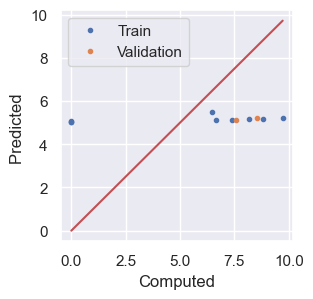

Epoch: 11, Train MAE: 3.7625, Val MAE: 2.9200
Epoch: 12, Train MAE: 3.7606, Val MAE: 2.9151
Epoch: 13, Train MAE: 3.7527, Val MAE: 2.9099
Epoch: 14, Train MAE: 3.7405, Val MAE: 2.9040
Epoch: 15, Train MAE: 3.7408, Val MAE: 2.8975
Epoch: 16, Train MAE: 3.7294, Val MAE: 2.8903
Epoch: 17, Train MAE: 3.7233, Val MAE: 2.8823
Epoch: 18, Train MAE: 3.7161, Val MAE: 2.8737
Epoch: 19, Train MAE: 3.7048, Val MAE: 2.8648
Epoch: 20, Train MAE: 3.7033, Val MAE: 2.8558


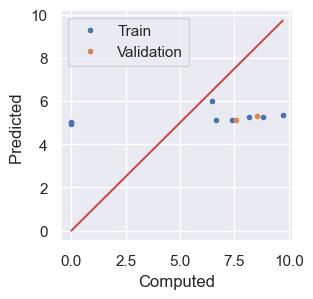

Epoch: 21, Train MAE: 3.6897, Val MAE: 2.8462
Epoch: 22, Train MAE: 3.6936, Val MAE: 2.8359
Epoch: 23, Train MAE: 3.6864, Val MAE: 2.8251
Epoch: 24, Train MAE: 3.6663, Val MAE: 2.8136
Epoch: 25, Train MAE: 3.6608, Val MAE: 2.8017
Epoch: 26, Train MAE: 3.6571, Val MAE: 2.7897
Epoch: 27, Train MAE: 3.6449, Val MAE: 2.7772
Epoch: 28, Train MAE: 3.6324, Val MAE: 2.7641
Epoch: 29, Train MAE: 3.6319, Val MAE: 2.7506
Epoch: 30, Train MAE: 3.6138, Val MAE: 2.7366


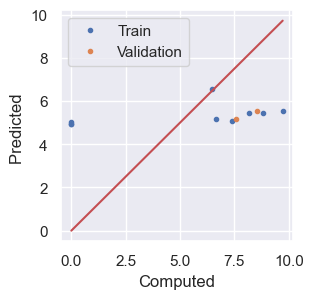

Epoch: 31, Train MAE: 3.6151, Val MAE: 2.7224
Epoch: 32, Train MAE: 3.6081, Val MAE: 2.7077
Epoch: 33, Train MAE: 3.5961, Val MAE: 2.6924
Epoch: 34, Train MAE: 3.5817, Val MAE: 2.6765
Epoch: 35, Train MAE: 3.5551, Val MAE: 2.6596
Epoch: 36, Train MAE: 3.5425, Val MAE: 2.6420
Epoch: 37, Train MAE: 3.5419, Val MAE: 2.6239
Epoch: 38, Train MAE: 3.5240, Val MAE: 2.6053
Epoch: 39, Train MAE: 3.5246, Val MAE: 2.5864
Epoch: 40, Train MAE: 3.5071, Val MAE: 2.5675


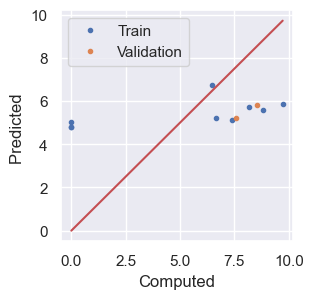

Epoch: 41, Train MAE: 3.4919, Val MAE: 2.5483
Epoch: 42, Train MAE: 3.4776, Val MAE: 2.5282
Epoch: 43, Train MAE: 3.4721, Val MAE: 2.5076
Epoch: 44, Train MAE: 3.4521, Val MAE: 2.4864
Epoch: 45, Train MAE: 3.4631, Val MAE: 2.4648
Epoch: 46, Train MAE: 3.4250, Val MAE: 2.4430
Epoch: 47, Train MAE: 3.4055, Val MAE: 2.4204
Epoch: 48, Train MAE: 3.3656, Val MAE: 2.3970
Epoch: 49, Train MAE: 3.3702, Val MAE: 2.3732
Epoch: 50, Train MAE: 3.3297, Val MAE: 2.3487


In [ ]:
# Train the model
train_losses = []
val_losses   = []
for epoch in np.arange(0, n_epochs):
    train_loss, train_predictions, train_ground_truths = clm.train(model, criterion, train_loader,
                                                                   target_factor,
                                                                   standardized_parameters['target_mean'],
                                                                   optimizer)
    val_loss,   val_predictions,   val_ground_truths   =  clm.test(model, criterion, val_loader,
                                                                   target_factor,
                                                                   standardized_parameters['target_mean'])

    # Convert to original units
    train_loss = np.sum(np.sqrt(train_loss) * target_factor)
    val_loss   = np.sum(np.sqrt(val_loss)   * target_factor)

    if epoch%10 == 0:
        cld.parity_plot(train=np.array([train_ground_truths, train_predictions]),
                        validation=np.array([val_ground_truths, val_predictions]))
    
    # Append losses
    train_losses.append(train_loss)
    val_losses.append(val_loss)

    # Check early stopping criteria
    early_stopping(val_loss, model)

    if early_stopping.early_stop:
        print('Early stopping')
        break

    print(f'Epoch: {epoch+1}, Train MAE: {train_loss:.4f}, Val MAE: {val_loss:.4f}')

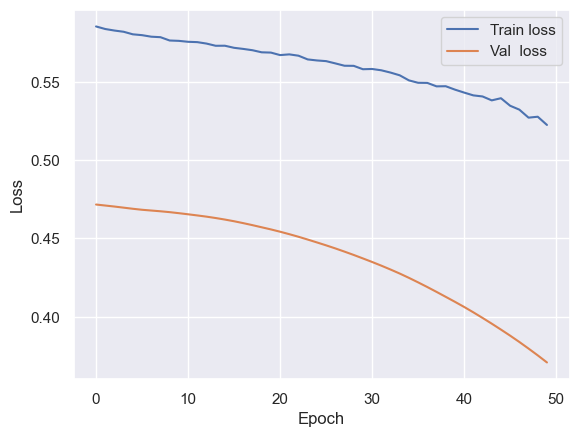

In [ ]:
cld.losses_plot(train_losses=train_losses,
                val_losses=val_losses,
                to_log=True)

# Check test data

In [ ]:
model = clm.load_model(n_node_features, dropout, device, model_name=files_names['model'], mode='eval')
model

DataParallel(
  (module): GCNN(
    (conv1): GraphConv(4, 512)
    (conv2): GraphConv(512, 512)
    (linconv1): Linear(in_features=512, out_features=64, bias=True)
    (linconv2): Linear(in_features=64, out_features=16, bias=True)
    (lin): Linear(in_features=16, out_features=1, bias=True)
  )
)

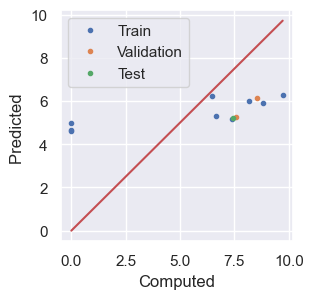

Train MAE: 3.3323, Val MAE: 2.3487, Test MAE: 2.2125


In [ ]:
train_loss, train_predictions, train_ground_truths = clm.test(model, criterion, train_loader,
                                                              target_factor,
                                                              standardized_parameters['target_mean'])
val_loss,   val_predictions,   val_ground_truths   = clm.test(model, criterion, val_loader,
                                                              target_factor,
                                                              standardized_parameters['target_mean'])
test_loss,  test_predictions,  test_ground_truths  = clm.test(model, criterion, test_loader,
                                                              target_factor,
                                                              standardized_parameters['target_mean'])

# Pass to energy units (same as initial Fv)
train_loss = np.sum(np.sqrt(train_loss) * target_factor)
val_loss   = np.sum(np.sqrt(val_loss)   * target_factor)
test_loss  = np.sum(np.sqrt(test_loss)  * target_factor)

cld.parity_plot(train=np.array([train_ground_truths, train_predictions]),
                validation=np.array([val_ground_truths, val_predictions]),
                test=np.array([test_ground_truths, test_predictions]),
                save_to=f'{timestamped_folder}/GCNN-training.pdf')

print(f'Train MAE: {train_loss:.4f}, Val MAE: {val_loss:.4f}, Test MAE: {test_loss:.4f}')

In [ ]:
import json

# Save detailed results to the timestamped model folder
results_data = {
    'timestamp': timestamp,
    'model_parameters': model_parameters,
    'training_history': {
        'train_losses': [float(loss) for loss in train_losses],
        'val_losses': [float(loss) for loss in val_losses],
        'epochs_completed': len(train_losses)
    },
    'final_metrics': {
        'train_mae': float(train_loss),
        'val_mae': float(val_loss),
        'test_mae': float(test_loss)
    },
    'predictions': {
        'train': {
            'predicted': train_predictions.tolist(),
            'actual': train_ground_truths.tolist()
        },
        'validation': {
            'predicted': val_predictions.tolist(),
            'actual': val_ground_truths.tolist()
        },
        'test': {
            'predicted': test_predictions.tolist(),
            'actual': test_ground_truths.tolist()
        }
    }
}

results_file = f'{timestamped_folder}/model_results_{timestamp}.json'
with open(results_file, 'w') as f:
    json.dump(results_data, f, indent=4)

print(f'Model results saved to: {results_file}')

In [172]:
import importlib
importlib.reload(cld)

<module 'libraries.dataset' from 'c:\\Users\\mateu\\Desktop\\gnn-material-science\\gnn-material-science\\gnn-material-science\\libraries\\dataset.py'>